# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [72]:
import pymorphy3
import re
import pandas as pd
import numpy as np
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
import seaborn as sns
from matplotlib import pyplot as plt

## Preparing DataSet

In [4]:
df = pd.read_csv("data/McDonald_s_Reviews.csv", encoding="latin1")#, lineterminator='\n')

In [5]:
df.head()

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  str    
 2   category       33396 non-null  str    
 3   store_address  33396 non-null  str    
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  str    
 7   review_time    33396 non-null  str    
 8   review         33396 non-null  str    
 9   rating         33396 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 2.5 MB


In [8]:
len(df["store_address"].unique())

40

In [9]:
df = df[["reviewer_id", "rating_count", "review_time", "review", "rating"]]

In [10]:
morph = pymorphy3.MorphAnalyzer()

# Lemmatazing

In [11]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kazak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kazak\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\kazak\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [12]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Маппинг тегов частей речи NLTK в понятные для WordNet категории"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_english_nltk(text):
    if not isinstance(text, str):
        return []

    # Токенизируем текст по словам
    words = nltk.word_tokenize(text.lower())

    # Лемматизируем с учетом правильной части речи
    return [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in words if w.isalnum()]

In [14]:
vectorizer = TfidfVectorizer(max_features=500, tokenizer=lemmatize_english_nltk)
X = vectorizer.fit_transform(df['review'])

C:\Projects\Python Projects\Review Clastering\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [60]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 466216 stored elements and shape (33396, 500)>
  Coords	Values
  (0, 480)	0.19434391906963924
  (0, 113)	0.11338684293963099
  (0, 214)	0.09232517655366963
  (0, 245)	0.1717448375011515
  (0, 237)	0.13531820917197598
  (0, 394)	0.2061232089156125
  (0, 300)	0.12027724290008841
  (0, 276)	0.2175098510954403
  (0, 161)	0.1931753906960126
  (0, 205)	0.26134323780819235
  (0, 189)	0.09992384258612065
  (0, 10)	0.08342679308371093
  (0, 141)	0.21428767291619902
  (0, 47)	0.2000925406349495
  (0, 24)	0.07196168385031386
  (0, 332)	0.22841266418931436
  (0, 63)	0.11113052586963501
  (0, 290)	0.19181328246441529
  (0, 116)	0.2151154181952788
  (0, 466)	0.16265086884224983
  (0, 442)	0.16491001762929713
  (0, 127)	0.15882723672507326
  (0, 435)	0.21471872539495634
  (0, 450)	0.17710174601892634
  (0, 288)	0.2204756126984927
  :	:
  (33390, 462)	0.6154081094376417
  (33390, 472)	0.7882086391548797
  (33391, 432)	0.3276560531679927
  (

## K-means for Clustering

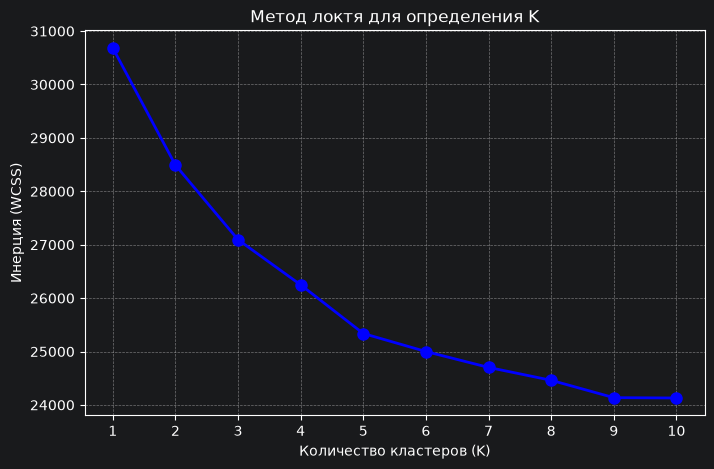

In [15]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Визуализация метода локтя
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.title('Метод локтя для определения K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Инерция (WCSS)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
num_clusters = 5

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

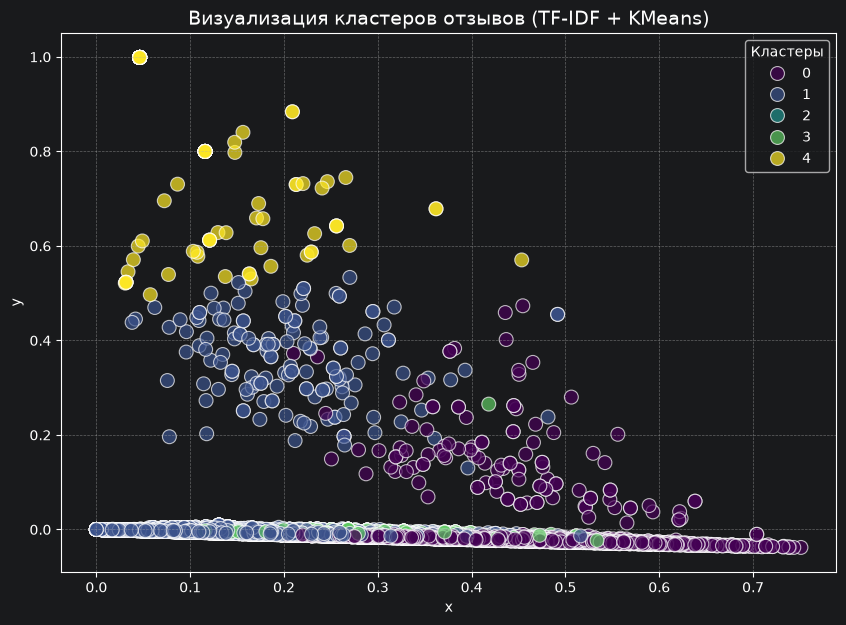

In [17]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

df['x'] = X_2d[:, 0]
df['y'] = X_2d[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='x',
    y='y',
    hue='cluster',
    palette='viridis',
    alpha=0.7,
    s=100
)

plt.title('Визуализация кластеров отзывов (TF-IDF + KMeans)', fontsize=14)
plt.legend(title='Кластеры')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

<Axes: xlabel='cluster', ylabel='Count'>

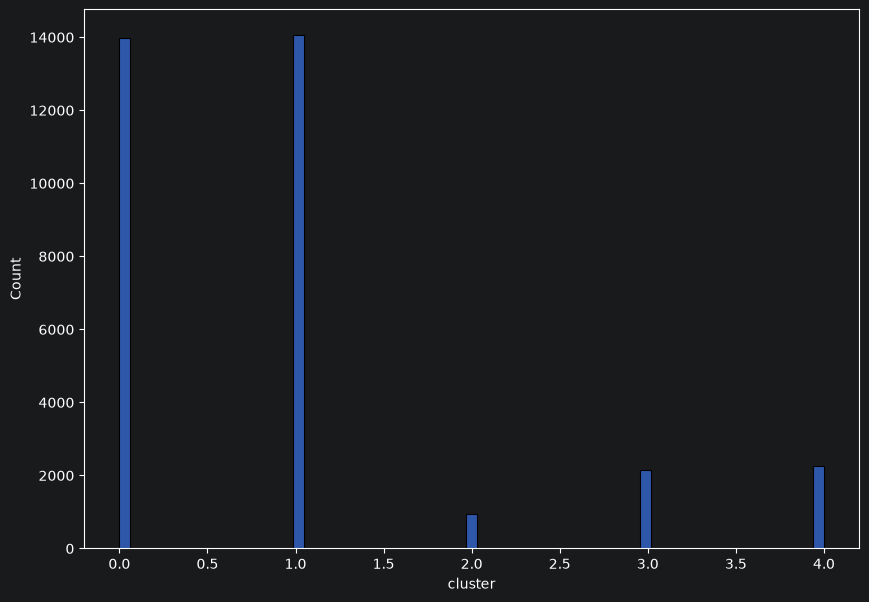

In [18]:
plt.figure(figsize=(10, 7))

sns.histplot(data=df, x='cluster')

In [24]:
df[df['cluster'] == 0]

,reviewer_id,rating_count,review_time,review,rating,cluster,x,y
0,1,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star,0,0.425154,-0.021427
1,2,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars,0,0.481377,-0.022127
2,3,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star,0,0.522545,-0.027394
4,5,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star,0,0.459128,-0.023761
5,6,"1,240",3 weeks ago,I work for door dash and they locked us all ou...,1 star,0,0.399330,-0.021144
...,...,...,...,...,...,...,...,...
33366,33367,"2,810",2 years ago,I love the app and the curbside ordering,5 stars,0,0.335952,-0.017172
33367,33368,"2,810",4 years ago,They robbed us and robbed us of everything. Th...,1 star,0,0.299991,-0.014365
33368,33369,"2,810",a year ago,The fries were old and cold.,2 stars,0,0.258803,-0.011901
33371,33372,"2,810",4 years ago,"All good, although when I went they didn't hav...",3 stars,0,0.319814,-0.016349


## DBSCAN for Clustering

In [62]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_dbscan = svd.fit_transform(X)

In [63]:
dbscan = DBSCAN(eps=0.99, min_samples=5)
df['cluster'] = dbscan.fit_predict(X)

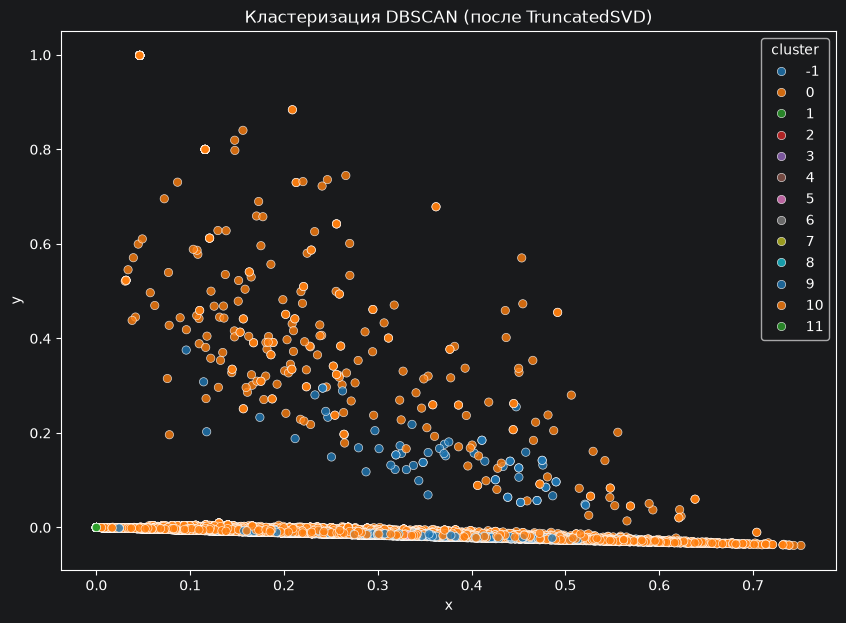

In [64]:
X_2d = X_dbscan[:, :2]
df['x'] = X_2d[:, 0]
df['y'] = X_2d[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='x', y='y', hue='cluster', palette='tab10', alpha=0.8)
plt.title('Кластеризация DBSCAN')
plt.show()

<Axes: xlabel='cluster', ylabel='Count'>

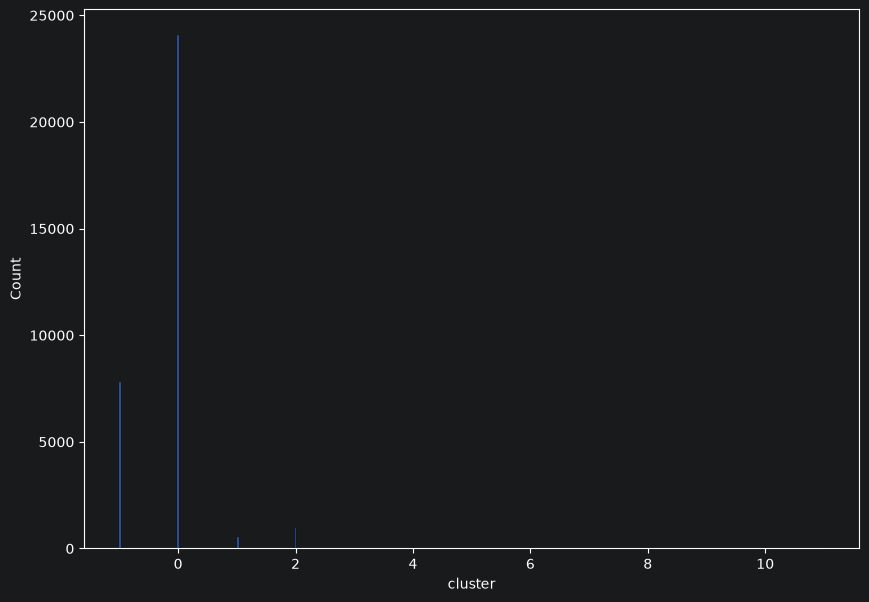

In [65]:
plt.figure(figsize=(10, 7))

sns.histplot(data=df, x='cluster')

## BERT

In [66]:
from sentence_transformers import SentenceTransformer

In [67]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df['review'].tolist(), show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Projects\Python Projects\Review Clastering\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kazak\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1044 [00:00<?, ?it/s]

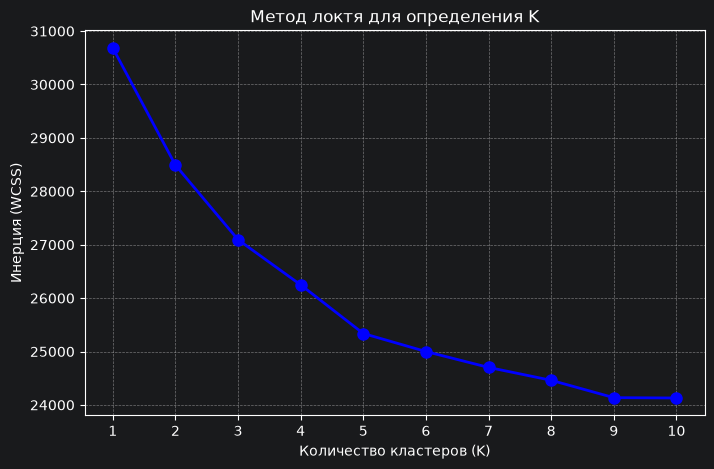

In [69]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Визуализация метода локтя
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.title('Метод локтя для определения K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Инерция (WCSS)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [70]:
df_sample = df.copy()

In [71]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_sample['cluster'] = kmeans.fit_predict(embeddings)

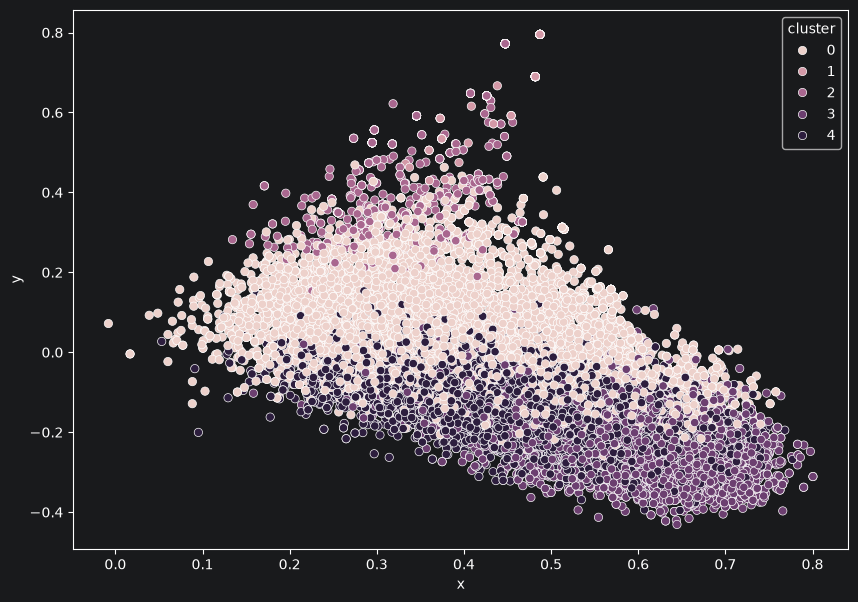

In [82]:
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(embeddings)

df_sample['x'] = coords[:, 0]
df_sample['y'] = coords[:, 1]


plt.figure(figsize=(10, 7))
fig = sns.scatterplot(
    df_sample,
    x='x',
    y='y',
    hue='cluster',
)

In [83]:
def extract_top_keywords(texts, top_n=7):
    """Извлекает важные слова и словосочетания из группы текстов с помощью TF-IDF"""
    tfidf = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2), # Берем одиночные слова и пары слов (bigrams)
        max_features=100
    )
    try:
        tfidf_matrix = tfidf.fit_transform(texts)
        scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
        feature_names = tfidf.get_feature_names_out()

        # Сортируем слова по важности
        top_indices = scores.argsort()[::-1][:top_n]
        return [feature_names[i] for i in top_indices]
    except Exception:
        return ["недостаточно данных"]

# Анализируем каждый кластер
for cluster_id in sorted(df_sample['cluster'].unique()):
    cluster_reviews = df_sample[df_sample['cluster'] == cluster_id]['review']
    keywords = extract_top_keywords(cluster_reviews, top_n=7)

    print(f"\n📌 [Кластер {cluster_id}] (Всего отзывов: {len(cluster_reviews)})")
    print(f"   🔑 Ключевые слова/темы: {', '.join(keywords)}")
    print("   💬 Пример отзыва:")
    sample_text = cluster_reviews.iloc[0].replace('\n', ' ')
    print(f"      \"{sample_text[:120]}...\"")


Кластер 0 (Всего отзывов: 10318)
   Ключевые слова/темы: service, good, food, fast, great, ½ï, place
   Пример отзыва:
      "With all the new upgrades everything looks great and clean great staff..."

Кластер 1 (Всего отзывов: 2272)
   Ключевые слова/темы: excellent, great, awesome, perfect, amazing, wonderful, great fantastic
   Пример отзыва:
      "Great..."

Кластер 2 (Всего отзывов: 3746)
   Ключевые слова/темы: good, neutral, poor, terrible, ok, nice, bad
   Пример отзыва:
      "Good..."

Кластер 3 (Всего отзывов: 7787)
   Ключевые слова/темы: mcdonald, ½ï, ½ï ½ï, food, mcdonalds, fries, good
   Пример отзыва:
      "It'd McDonalds. It is what it is as far as the food and atmosphere go. The staff here does make a difference. They are a..."

Кластер 4 (Всего отзывов: 9273)
   Ключевые слова/темы: order, ½ï, food, ½ï ½ï, service, drive, staff
   Пример отзыва:
      "Why does it look like someone spit on my food? I had a normal transaction,  everyone was chill and polite, but no